# 1. Install necessary libraries

In [27]:
# Install necessary libraries
!pip install --upgrade -q gspread scikit-learn pandas

# 2. Authenticate and access the Google Drive + Sheets

In [28]:
#Google Sheets Linking (Needs user authorization)
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

# 3. Import Datasets

Raw - Train/Validate, Evaluation

Group1 Preprocessed - Train/Validate, Evaluation

Group2 Preprocessed - Train/Validate, Evaluation

In [49]:
import pandas as pd

# Raw_Eval
wb_raw_eval = gc.open_by_url('https://docs.google.com/spreadsheets/d/1KsidfWCrywomIAbdlNg6Gn5rMER9E8gpI2AxGpNfjZ4/edit?usp=drive_link')
data_raw_eval = wb_raw_eval.get_worksheet(0).get_all_values()
df_raw_eval = pd.DataFrame(data_raw_eval[1:], columns=data_raw_eval[0])

# Raw_TrainValid
wb_raw_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1swxApDpgutQxNKr6GJHSr96PQZUxd_qcKAx8hlV7YOI/edit?usp=drive_link')
data_raw_tv = wb_raw_tv.get_worksheet(0).get_all_values()
df_raw_train_valid = pd.DataFrame(data_raw_tv[1:], columns=data_raw_tv[0])

In [50]:
# Group1_Preprocessed_Eval
wb_g1_eval = gc.open_by_url('https://docs.google.com/spreadsheets/d/1-7gT9ZaJbaG35HpCWQqJyhFo1Vl4AfQ-HeLLSWLlhdA/edit?usp=drive_link')
data_g1_eval = wb_g1_eval.get_worksheet(0).get_all_values()
df_g1_preprocessed_eval = pd.DataFrame(data_g1_eval[1:], columns=data_g1_eval[0])

# Group1_Preprocessed_TrainValid
wb_g1_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1py--oeZRWbSVVBqrsLe0WZXRqhfaS_ZcNYqHIiLOcvM/edit?usp=drive_link')
data_g1_tv = wb_g1_tv.get_worksheet(0).get_all_values()
df_g1_preprocessed_train_valid = pd.DataFrame(data_g1_tv[1:], columns=data_g1_tv[0])

In [51]:
# Group2_Preprocessed_Eval
wb_g2_eval = gc.open_by_url('https://docs.google.com/spreadsheets/d/1j3pF9gIkk_FiLEjT6STIxELDWC1EDm8Qxur849n-VFw/edit?usp=drive_link')
data_g2_eval = wb_g2_eval.get_worksheet(0).get_all_values()
df_g2_preprocessed_eval = pd.DataFrame(data_g2_eval[1:], columns=data_g2_eval[0])

# Group2_Preprocessed_TrainValid
wb_g2_tv = gc.open_by_url('https://docs.google.com/spreadsheets/d/1-rdT3VXb-0fi3kP96KVL4TWRwXG-sAPWeGcilLk_fTA/edit?usp=drive_link')
data_g2_tv = wb_g2_tv.get_worksheet(0).get_all_values()
df_g2_preprocessed_train_valid = pd.DataFrame(data_g2_tv[1:], columns=data_g2_tv[0])

# 4. N Gram Tokenization + TFIDF Vectorization

1. unigram and bigram tokenization

2. TFIDF = `TF(t,d) * IDF(t,D)`

    *t* is the term (word).

    *d* is the specific document.

    *D* is the collection of documents (corpus).

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Vectorization for Raw_TrainValid ---
print("Vectorizing Raw TrainValid text...")
tfidf_raw = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', max_features=10000)
X_raw_train_valid = tfidf_raw.fit_transform(df_raw_train_valid['text'].astype(str))

# --- Vectorization for Group1_Preprocessed_TrainValid ---
print("Vectorizing Group 1 Preprocessed TrainValid text...")
tfidf_g1 = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', max_features=10000)
X_g1_train_valid = tfidf_g1.fit_transform(df_g1_preprocessed_train_valid['text'].astype(str))

# --- Vectorization for Group2_Preprocessed_TrainValid ---
print("Vectorizing Group 2 Preprocessed TrainValid text...")
tfidf_g2 = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', max_features=10000)
X_g2_train_valid = tfidf_g2.fit_transform(df_g2_preprocessed_train_valid['text'].astype(str))

Vectorizing Raw TrainValid text...
Vectorizing Group 1 Preprocessed TrainValid text...
Vectorizing Group 2 Preprocessed TrainValid text...


# 5. Label Encoding (labels into numerical)

1. label_generic

2. label_specific

In [53]:
from sklearn.preprocessing import LabelEncoder

# --- Encoding for Raw_TrainValid ---
le_raw = LabelEncoder()
y_raw_specific = le_raw.fit_transform(df_raw_train_valid['label_specific'])
y_raw_generic = df_raw_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0)

# --- Encoding for Group 1 Preprocessed TrainValid ---
le_g1 = LabelEncoder()
y_g1_specific = le_g1.fit_transform(df_g1_preprocessed_train_valid['label_specific'])
y_g1_generic = df_g1_preprocessed_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0)

# --- Encoding for Group 2 Preprocessed TrainValid ---
le_g2 = LabelEncoder()
y_g2_specific = le_g2.fit_transform(df_g2_preprocessed_train_valid['label_specific'])
y_g2_generic = df_g2_preprocessed_train_valid['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0)

#6. Train (and Validate/Tune)

**Stratified 10-Fold**: This ensures that each fold of our cross-validation has the same proportion of observations with a given label as the whole dataset, which is crucial for handling potential class imbalances.

**GridSearchCV**: This allows us to systematically test different combinations of hyperparameters (for Binomial Logisitic Regression regularization strength `C`) to find the best configuration for our model.

Models:

```
Logistic Regression

Naive Bayes

Linear SVM

KNN

RF

XGBoost

Adaboost
```



In [34]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Shared Stratified K-Fold Strategy
skf_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

## 6.1. Organize Datasets

In [35]:
# Grouping the 3 datasets and their respective labels
datasets = {
    'Raw': {
        'X': X_raw_train_valid,
        'y_bin': y_raw_generic,
        'y_multi': y_raw_specific
    },
    'Group1': {
        'X': X_g1_train_valid,
        'y_bin': y_g1_generic,
        'y_multi': y_g1_specific
    },
    'Group2': {
        'X': X_g2_train_valid,
        'y_bin': y_g2_generic,
        'y_multi': y_g2_specific
    }
}

## 6.2. Define Grid Search Hyperparameters

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

# We will reduce our 10,000 TF-IDF features down to 300 dense components/dims
n_comp = 300

# --- BINARY MODELS ---
models_binary = {
    # No Pipeline needed for these:
    'LogisticRegression': (LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42), {'C': [0.01, 0.1, 1, 10, 100]}),
    'NaiveBayes': (MultinomialNB(), {'alpha': [0.01, 0.1, 1.0, 10.0]}),
    'LinearSVM': (SVC(kernel='linear', probability=True, random_state=42), {'C': [0.1, 1, 10]}),

    # Pipeline needed for these (Note the 'clf__' prefix in the parameter grid to target the classifier step):
    'KNN': (Pipeline([('svd', TruncatedSVD(n_components=n_comp, random_state=42)), ('clf', KNeighborsClassifier())]),
            {'clf__n_neighbors': [3, 5, 7], 'clf__weights': ['uniform', 'distance']}),

    'RandomForest': (Pipeline([('svd', TruncatedSVD(n_components=n_comp, random_state=42)), ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
                     {'clf__n_estimators': [100, 200], 'clf__max_depth': [None, 20]}),

    'AdaBoost': (Pipeline([('svd', TruncatedSVD(n_components=n_comp, random_state=42)), ('clf', AdaBoostClassifier(random_state=42))]),
                 {'clf__n_estimators': [50, 100], 'clf__learning_rate': [0.1, 1.0]}),

    'XGBoost': (Pipeline([('svd', TruncatedSVD(n_components=n_comp, random_state=42)), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1))]),
                {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.1, 0.2], 'clf__max_depth': [3, 6]})
}

# --- MULTI-CLASS MODELS ---
models_multi = {
    # No Pipeline needed:
    'LogisticRegression': (LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42), {'C': [0.01, 0.1, 1, 10, 100]}),
    'NaiveBayes': (MultinomialNB(), {'alpha': [0.01, 0.1, 1.0, 10.0]}),
    'LinearSVM': (SVC(kernel='linear', probability=True, random_state=42), {'C': [0.1, 1, 10]}),

    # Pipeline needed:
    'KNN': (Pipeline([('svd', TruncatedSVD(n_components=n_comp, random_state=42)), ('clf', KNeighborsClassifier())]),
            {'clf__n_neighbors': [3, 5, 7], 'clf__weights': ['uniform', 'distance']}),

    'RandomForest': (Pipeline([('svd', TruncatedSVD(n_components=n_comp, random_state=42)), ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
                     {'clf__n_estimators': [100, 200], 'clf__max_depth': [None, 20]}),

    'AdaBoost': (Pipeline([('svd', TruncatedSVD(n_components=n_comp, random_state=42)), ('clf', AdaBoostClassifier(random_state=42))]),
                 {'clf__n_estimators': [50, 100], 'clf__learning_rate': [0.1, 1.0]}),

    'XGBoost': (Pipeline([('svd', TruncatedSVD(n_components=n_comp, random_state=42)), ('clf', XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_jobs=-1))]),
                {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.1, 0.2], 'clf__max_depth': [3, 6]})
}

## 6.3. Training Loop - 3 datasets, 2 separte labels, grid search, 10-fold CV

In [37]:
# Dictionary to store all our trained, optimized models
trained_models = {
    'Raw': {'Binary': {}, 'Multi': {}},
    'Group1': {'Binary': {}, 'Multi': {}},
    'Group2': {'Binary': {}, 'Multi': {}}
}

for data_name, data_dict in datasets.items():
    print(f"\n{'='*40}")
    print(f"TRAINING ON DATASET: {data_name}")
    print(f"{'='*40}")

    X_current = data_dict['X']

    # 1. Train Binary Models
    print("\n--- Running Binary Classification (Generic Labels) ---")
    y_bin_current = data_dict['y_bin']

    for model_name, (model, param_grid) in models_binary.items():
        print(f"Training {model_name}...")
        grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=skf_strategy,
                            scoring={'f1': 'f1', 'roc_auc': 'roc_auc'}, refit='roc_auc', n_jobs=-1)
        grid.fit(X_current, y_bin_current)

        # Save best model
        trained_models[data_name]['Binary'][model_name] = grid.best_estimator_
        print(f"  Best ROC-AUC: {grid.best_score_:.4f} | Params: {grid.best_params_}")

    # 2. Train Multi-class Models
    print("\n--- Running Multi-class Classification (Specific Labels) ---")
    y_multi_current = data_dict['y_multi']

    for model_name, (model, param_grid) in models_multi.items():
        print(f"Training {model_name}...")
        grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=skf_strategy,
                            scoring={'f1_macro': 'f1_macro', 'roc_auc_ovr': 'roc_auc_ovr'}, refit='roc_auc_ovr', n_jobs=-1)
        grid.fit(X_current, y_multi_current)

        # Save best model
        trained_models[data_name]['Multi'][model_name] = grid.best_estimator_
        print(f"  Best ROC-AUC (OVR): {grid.best_score_:.4f} | Params: {grid.best_params_}")

print("\nAll training complete! Models are saved in the 'trained_models' dictionary.")


TRAINING ON DATASET: Raw

--- Running Binary Classification (Generic Labels) ---
Training LogisticRegression...
  Best ROC-AUC: 0.9996 | Params: {'C': 100}
Training NaiveBayes...
  Best ROC-AUC: 0.9986 | Params: {'alpha': 0.01}
Training LinearSVM...
  Best ROC-AUC: 0.9997 | Params: {'C': 10}
Training KNN...
  Best ROC-AUC: 0.9936 | Params: {'clf__n_neighbors': 5, 'clf__weights': 'distance'}
Training RandomForest...
  Best ROC-AUC: 0.9985 | Params: {'clf__max_depth': 20, 'clf__n_estimators': 200}
Training AdaBoost...
  Best ROC-AUC: 0.9950 | Params: {'clf__learning_rate': 1.0, 'clf__n_estimators': 100}
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:12:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Best ROC-AUC: 0.9987 | Params: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 200}

--- Running Multi-class Classification (Specific Labels) ---
Training LogisticRegression...
  Best ROC-AUC (OVR): 0.9999 | Params: {'C': 100}
Training NaiveBayes...
  Best ROC-AUC (OVR): 0.9996 | Params: {'alpha': 0.01}
Training LinearSVM...
  Best ROC-AUC (OVR): 0.9999 | Params: {'C': 10}
Training KNN...
  Best ROC-AUC (OVR): 0.9784 | Params: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Training RandomForest...
  Best ROC-AUC (OVR): 0.9991 | Params: {'clf__max_depth': None, 'clf__n_estimators': 200}
Training AdaBoost...
  Best ROC-AUC (OVR): 0.9427 | Params: {'clf__learning_rate': 1.0, 'clf__n_estimators': 100}
Training XGBoost...
  Best ROC-AUC (OVR): 0.9996 | Params: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 200}

TRAINING ON DATASET: Group1

--- Running Binary Classification (Generic Labels) ---
Training LogisticRegression...
  Best ROC-AUC

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:23:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Best ROC-AUC: 0.9983 | Params: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 200}

--- Running Multi-class Classification (Specific Labels) ---
Training LogisticRegression...
  Best ROC-AUC (OVR): 0.9999 | Params: {'C': 100}
Training NaiveBayes...
  Best ROC-AUC (OVR): 0.9996 | Params: {'alpha': 0.01}
Training LinearSVM...
  Best ROC-AUC (OVR): 0.9999 | Params: {'C': 10}
Training KNN...
  Best ROC-AUC (OVR): 0.9750 | Params: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Training RandomForest...
  Best ROC-AUC (OVR): 0.9992 | Params: {'clf__max_depth': 20, 'clf__n_estimators': 200}
Training AdaBoost...
  Best ROC-AUC (OVR): 0.9293 | Params: {'clf__learning_rate': 1.0, 'clf__n_estimators': 100}
Training XGBoost...
  Best ROC-AUC (OVR): 0.9995 | Params: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 200}

TRAINING ON DATASET: Group2

--- Running Binary Classification (Generic Labels) ---
Training LogisticRegression...
  Best ROC-AUC: 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:36:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Best ROC-AUC: 0.9990 | Params: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 200}

--- Running Multi-class Classification (Specific Labels) ---
Training LogisticRegression...
  Best ROC-AUC (OVR): 0.9999 | Params: {'C': 100}
Training NaiveBayes...
  Best ROC-AUC (OVR): 0.9996 | Params: {'alpha': 0.01}
Training LinearSVM...
  Best ROC-AUC (OVR): 0.9999 | Params: {'C': 1}
Training KNN...
  Best ROC-AUC (OVR): 0.9779 | Params: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Training RandomForest...
  Best ROC-AUC (OVR): 0.9992 | Params: {'clf__max_depth': 20, 'clf__n_estimators': 200}
Training AdaBoost...
  Best ROC-AUC (OVR): 0.9420 | Params: {'clf__learning_rate': 1.0, 'clf__n_estimators': 100}
Training XGBoost...
  Best ROC-AUC (OVR): 0.9996 | Params: {'clf__learning_rate': 0.2, 'clf__max_depth': 3, 'clf__n_estimators': 200}

All training complete! Models are saved in the 'trained_models' dictionary.


In [ ]:
#EX: best_rf_g1_multi = trained_models['Group1']['Multi']['RandomForest']

## 6.4. Save DBTL1 Assets - TFIDF Vectorier, Best Models...

In [38]:
from google.colab import drive
import os

# This will prompt a popup to authorize Drive access
drive.mount('/content/drive')

# Create a folder in your Drive to keep things organized
save_path = '/content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL1'
os.makedirs(save_path, exist_ok=True)
print(f"Directory ready at: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directory ready at: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL1


In [39]:
import joblib

print("Saving models to Google Drive...")

for data_name, tasks in trained_models.items():
    for task_name, models in tasks.items():
        for model_name, best_model in models.items():

            # Create a clean file name (e.g., "Group1_Multi_RandomForest.joblib")
            file_name = f"{data_name}_{task_name}_{model_name}.joblib"
            full_file_path = os.path.join(save_path, file_name)

            # Save the model
            joblib.dump(best_model, full_file_path)

print("All 42 models have been successfully saved to your Drive!")

Saving models to Google Drive...
All 42 models have been successfully saved to your Drive!


In [40]:
print("Saving Vectorizers and Encoders...")

# Save Vectorizers
joblib.dump(tfidf_raw, os.path.join(save_path, 'tfidf_raw.joblib'))
joblib.dump(tfidf_g1, os.path.join(save_path, 'tfidf_g1.joblib'))
joblib.dump(tfidf_g2, os.path.join(save_path, 'tfidf_g2.joblib'))

# Save Label Encoders
joblib.dump(le_raw, os.path.join(save_path, 'le_raw.joblib'))
joblib.dump(le_g1, os.path.join(save_path, 'le_g1.joblib'))
joblib.dump(le_g2, os.path.join(save_path, 'le_g2.joblib'))

print("Vectorizers and Encoders saved successfully!")

Saving Vectorizers and Encoders...
Vectorizers and Encoders saved successfully!


#7. Evaluation of Models

Reload Models, Encoders, Dictionaries

In [44]:
from google.colab import drive
import os
import joblib

# Authorize Drive access
drive.mount('/content/drive')

# Point to your Data Club shared drive folder
load_path = '/content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL1'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
print("Loading Vectorizers and Encoders...")

# Load Vectorizers
tfidf_raw = joblib.load(os.path.join(load_path, 'tfidf_raw.joblib'))
tfidf_g1 = joblib.load(os.path.join(load_path, 'tfidf_g1.joblib'))
tfidf_g2 = joblib.load(os.path.join(load_path, 'tfidf_g2.joblib'))

# Load Label Encoders
le_raw = joblib.load(os.path.join(load_path, 'le_raw.joblib'))
le_g1 = joblib.load(os.path.join(load_path, 'le_g1.joblib'))
le_g2 = joblib.load(os.path.join(load_path, 'le_g2.joblib'))

print("Vectorizers and Encoders loaded successfully!")

Loading Vectorizers and Encoders...
Vectorizers and Encoders loaded successfully!


In [46]:
print("Loading all 42 models back into memory...")

# Recreate the empty dictionary structure
loaded_trained_models = {
    'Raw': {'Binary': {}, 'Multi': {}},
    'Group1': {'Binary': {}, 'Multi': {}},
    'Group2': {'Binary': {}, 'Multi': {}}
}

# Define the lists based on how we trained them
datasets_names = ['Raw', 'Group1', 'Group2']
task_names = ['Binary', 'Multi']
model_names = ['LogisticRegression', 'NaiveBayes', 'LinearSVM', 'KNN', 'RandomForest', 'AdaBoost', 'XGBoost']

# Loop through and load each model
for data_name in datasets_names:
    for task_name in task_names:
        for model_name in model_names:

            # Reconstruct the exact file name
            file_name = f"{data_name}_{task_name}_{model_name}.joblib"
            full_file_path = os.path.join(load_path, file_name)

            # Check if the file exists, then load it
            if os.path.exists(full_file_path):
                loaded_trained_models[data_name][task_name][model_name] = joblib.load(full_file_path)

print("All models successfully loaded into the 'loaded_trained_models' dictionary!")

Loading all 42 models back into memory...
All models successfully loaded into the 'loaded_trained_models' dictionary!


##7.1. Defining Custom Cost Function

#### Function:
`Cost = (15 * False Negatives) + False Positives`.

A False Negative is defined as a Phishing email incorrectly marked as Legit. This is penalized 15x

A False Positive as a Legit email incorrectly marked as Phishing. This is penalized 1x

In [47]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_custom_cost(y_true, y_pred):
    """
    Cost = (15 * False Negatives) + False Positives
    False Negative: Actual Phishing (1), Predicted Legit (0) - Penalized 15x
    False Positive: Actual Legit (0), Predicted Phishing (1) - Penalized 1x
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    false_negatives = np.sum((y_true == 1) & (y_pred == 0))
    false_positives = np.sum((y_true == 0) & (y_pred == 1))

    return (15 * false_negatives) + false_positives

##7.2. Grouping Eval Data

In [54]:
# Grouping the Eval sets with their corresponding pre-fitted vectorizers and encoders
eval_datasets = {
    'Raw': {
        'df': df_raw_eval,
        'tfidf': tfidf_raw,
        'le': le_raw
    },
    'Group1': {
        'df': df_g1_preprocessed_eval,
        'tfidf': tfidf_g1,
        'le': le_g1
    },
    'Group2': {
        'df': df_g2_preprocessed_eval,
        'tfidf': tfidf_g2,
        'le': le_g2
    }
}

##7.3. Evaluation Loop - 3 Eval Sets, 2 Labels/Tasks, 3 Metrics (F1, AUCROC, Custom)

In [55]:
results_list = []
confusion_matrices = {}

print("Starting Evaluation on all 42 models...\n")

for data_name, config in eval_datasets.items():
    print(f"Evaluating {data_name} Dataset...")

    df_eval = config['df']
    tfidf = config['tfidf']
    le = config['le']

    # 1. Transform the Text using the pre-fitted vectorizer
    X_test = tfidf.transform(df_eval['text'].astype(str))

    # 2. Encode the True Labels
    # Generic (Binary)
    y_eval_bin = df_eval['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0).values

    # Specific (Multi-class) using the pre-fitted LabelEncoder
    y_eval_multi = le.transform(df_eval['label_specific'])

    # Create mapping for Multi-class Cost calculation (converting specific back to binary just for the cost metric)
    specific_to_generic_map = {i: (1 if 'phishing' in cls_name else 0) for i, cls_name in enumerate(le.classes_)}
    y_eval_multi_mapped = np.array([specific_to_generic_map[t] for t in y_eval_multi])

    # --- Evaluate BINARY Models ---
    for model_name, model in trained_models[data_name]['Binary'].items():
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] # Probability of '1' (phishing)

        f1 = f1_score(y_eval_bin, y_pred)
        auc = roc_auc_score(y_eval_bin, y_proba)
        cost = calculate_custom_cost(y_eval_bin, y_pred)
        cm = confusion_matrix(y_eval_bin, y_pred)

        # Save results
        results_list.append({
            'Dataset': data_name, 'Task': 'Binary', 'Model': model_name,
            'F1_Score': f1, 'ROC_AUC': auc, 'Custom_Cost': cost
        })
        confusion_matrices[f"{data_name}_Binary_{model_name}"] = cm

    # --- Evaluate MULTI-CLASS Models ---
    for model_name, model in trained_models[data_name]['Multi'].items():
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test) # Probabilities for all classes

        f1 = f1_score(y_eval_multi, y_pred, average='macro')
        auc = roc_auc_score(y_eval_multi, y_proba, multi_class='ovr', average='macro')

        # Calculate custom cost for multi-class by mapping predictions back to generic binary
        y_pred_mapped = np.array([specific_to_generic_map[p] for p in y_pred])
        cost = calculate_custom_cost(y_eval_multi_mapped, y_pred_mapped)
        cm = confusion_matrix(y_eval_multi, y_pred)

        # Save results
        results_list.append({
            'Dataset': data_name, 'Task': 'Multi-Class', 'Model': model_name,
            'F1_Score': f1, 'ROC_AUC': auc, 'Custom_Cost': cost
        })
        confusion_matrices[f"{data_name}_Multi_{model_name}"] = cm

print("\nEvaluation Complete!")

Starting Evaluation on all 42 models...

Evaluating Raw Dataset...
Evaluating Group1 Dataset...
Evaluating Group2 Dataset...

Evaluation Complete!


#8. Reporting of Results

Saving Results First - Master Eval Results Dataframe and Confusion Matricies

In [58]:
import os
import joblib


# Convert to DataFrame and sort to find the best models easily
results_df = pd.DataFrame(results_list)

# Sorting by Dataset, Task, and then by lowest Custom Cost
results_df = results_df.sort_values(by=['Dataset', 'Task', 'Custom_Cost', 'ROC_AUC'], ascending=[True, True, True, False])


print("Saving evaluation results and confusion matrices to Shared Drive...")

# 1. Save the Master DataFrame as a CSV
csv_file_path = os.path.join(save_path, 'Master_Evaluation_Results.csv')
results_df.to_csv(csv_file_path, index=False)
print(f"Master DataFrame saved to: {csv_file_path}")

# 2. Save the Confusion Matrices dictionary
cm_file_path = os.path.join(save_path, 'All_Confusion_Matrices.joblib')
joblib.dump(confusion_matrices, cm_file_path)
print(f"Confusion Matrices dictionary saved to: {cm_file_path}")

print("\nAll evaluation artifacts successfully saved!")

Saving evaluation results and confusion matrices to Shared Drive...
Master DataFrame saved to: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL1/Master_Evaluation_Results.csv
Confusion Matrices dictionary saved to: /content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/DBTL1/All_Confusion_Matrices.joblib

All evaluation artifacts successfully saved!


##8.1. Results DataFrame

In [59]:
# Display the table
display(results_df)

,Dataset,Task,Model,F1_Score,ROC_AUC,Custom_Cost
14,Group1,Binary,LogisticRegression,0.997500,0.999888,16
16,Group1,Binary,LinearSVM,0.997500,0.999800,16
17,Group1,Binary,KNN,0.966019,0.995809,56
18,Group1,Binary,RandomForest,0.991239,0.999425,63
20,Group1,Binary,XGBoost,0.988736,0.999619,79
15,Group1,Binary,NaiveBayes,0.987500,0.999412,80
19,Group1,Binary,AdaBoost,0.967662,0.994956,180
21,Group1,Multi-Class,LogisticRegression,0.996250,0.999960,45
23,Group1,Multi-Class,LinearSVM,0.995000,0.999948,60
24,Group1,Multi-Class,KNN,0.945863,0.982318,80


In [60]:
####BEST MODELS

def highlight_top_3_models(df):
    print("🏆 TOP 3 BEST PERFORMING MODELS (Lowest Custom Cost) 🏆")
    print("-" * 65)

    # Sort values: Primary = Custom_Cost (Lower is better)
    # Tie-breaker = ROC_AUC (Higher is better)
    top_3 = df.sort_values(by=['Custom_Cost', 'ROC_AUC'], ascending=[True, False]).head(3)

    # Reset index for clean iteration
    top_3 = top_3.reset_index(drop=True)

    # Loop through and print the results beautifully
    for index, row in top_3.iterrows():
        print(f"Rank {index + 1}: {row['Model']} trained on '{row['Dataset']}' ({row['Task']})")
        print(f"   -> Custom Cost: {row['Custom_Cost']}")
        print(f"   -> ROC-AUC:     {row['ROC_AUC']:.4f}")
        print(f"   -> F1 Score:    {row['F1_Score']:.4f}\n")

    return top_3

# Run the function on your master results dataframe
best_models_df = highlight_top_3_models(results_df)
print(best_models_df)

🏆 TOP 3 BEST PERFORMING MODELS (Lowest Custom Cost) 🏆
-----------------------------------------------------------------
Rank 1: LogisticRegression trained on 'Group1' (Binary)
   -> Custom Cost: 16
   -> ROC-AUC:     0.9999
   -> F1 Score:    0.9975

Rank 2: LinearSVM trained on 'Group1' (Binary)
   -> Custom Cost: 16
   -> ROC-AUC:     0.9998
   -> F1 Score:    0.9975

Rank 3: RandomForest trained on 'Raw' (Binary)
   -> Custom Cost: 16
   -> ROC-AUC:     0.9996
   -> F1 Score:    0.9975

  Dataset    Task               Model  F1_Score   ROC_AUC  Custom_Cost
0  Group1  Binary  LogisticRegression    0.9975  0.999888           16
1  Group1  Binary           LinearSVM    0.9975  0.999800           16
2     Raw  Binary        RandomForest    0.9975  0.999563           16


##8.2. Confusion Mtx Visualization

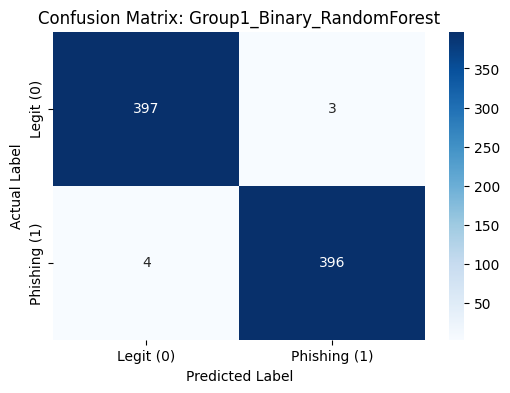

In [61]:
# Define which model's matrix you want to see
matrix_key = "Group1_Binary_RandomForest"
cm = confusion_matrices[matrix_key]

# Plot it
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit (0)', 'Phishing (1)'],
            yticklabels=['Legit (0)', 'Phishing (1)'])
plt.title(f'Confusion Matrix: {matrix_key}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [1]:
# Define which model's matrix you want to see
matrix_key = "Raw_Multi_LinearSVM"
cm = confusion_matrices[matrix_key]

# Get the actual class names from the LabelEncoder for the 'Raw' dataset's multi-class labels
class_names = le_raw.classes_

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f'Confusion Matrix: {matrix_key}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

NameError: name 'confusion_matrices' is not defined

In [2]:
import pandas as pd

# Re-create results_df to ensure it's available in this cell's scope
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by=['Dataset', 'Task', 'Custom_Cost', 'ROC_AUC'], ascending=[True, True, True, False])

average_f1_group1 = results_df[results_df['Dataset'] == 'Group1']['F1_Score'].mean()
average_f1_group2 = results_df[results_df['Dataset'] == 'Group2']['F1_Score'].mean()

print(f"Average F1 Score for Group1: {average_f1_group1:.4f}")
print(f"Average F1 Score for Group2: {average_f1_group2:.4f}")

NameError: name 'results_df' is not defined